In [13]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
from scipy.linalg import svdvals
import torch
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
import json

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util \
    import MetaData, NTKCalculator, StepCalculatorBase, StepCalculatorEtaNtk, StepCalculatorEtaAveragedNtk
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

import logging

In [14]:
logging.basicConfig(filename="log_criticality_step_eminst.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### MNIST dataset

MNIST dataset is used which contains 60000 28x28 images of handwritten digits from 0 to 9. 

In [15]:
# use it to conver from PIL to torch.Tensor
image_transform = ToTensor()

train_dataset = EMNIST(root=DATASET_PATH, split='letters', train=True, download=True, transform=image_transform)
test_dataset = EMNIST(root=DATASET_PATH, split='letters', train=False, download=True, transform=image_transform)

In [16]:
BATCH_SIZE = 96 #128 #64 #

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
)

Data example:

Feature batch shape: torch.Size([96, 1, 28, 28])
Labels batch shape: torch.Size([96])
Labels: [[21, 18, 4, 24, 22, 25, 24, 12], [26, 3, 24, 7, 11, 1, 6, 23], [26, 7, 22, 10, 14, 22, 5, 6], [4, 25, 19, 2, 19, 20, 14, 7], [14, 18, 25, 6, 24, 24, 13, 19], [1, 11, 4, 21, 20, 24, 5, 7], [14, 11, 14, 3, 7, 7, 7, 4], [23, 11, 2, 22, 3, 11, 20, 18], [19, 1, 16, 19, 11, 8, 5, 17], [18, 6, 2, 19, 26, 26, 21, 23], [24, 19, 2, 18, 25, 10, 11, 7], [16, 12, 15, 9, 10, 19, 3, 6]]


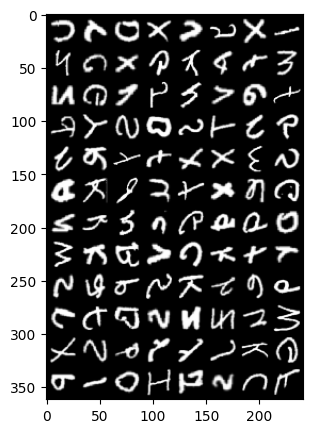

In [17]:
GRID_ROW_SIZE=8
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
#img = train_features[0].squeeze()
images = make_grid(train_features, GRID_ROW_SIZE).permute(1, 2, 0)
labels = train_labels.view(-1, GRID_ROW_SIZE).tolist()
print(f"Labels: {labels}")
plt.figure(figsize=(10, 5))
plt.imshow(images, cmap="gray")
plt.show()


In [18]:
INPUT_DIM = 28 * 28
OUTPUT_DIM = 26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 500, 200

lb, lw = 1e-2, 7.5 #1e-2,1,1 #1e-2, 1e-2, 1
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = lb, lw = lw)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available


##### UTILS

In [19]:
def save_dict(dict, dir):
    with open(dir + "/history.json", "w") as ff:
        ff.write(json.dumps(dict))
        ff.close()

def load_dict(dir):
    with open(dir + "/history.json", "r") as ff:
        dict = json.load(ff)
        ff.close()
        return dict

def flatten2d(HL):  #HL - [output_dim, output_dim, batch_size, batch_size]
    tmp = np.moveaxis(HL, 1, 2)
    dim = tmp.shape
    return np.reshape(tmp, (dim[0]*dim[1], dim[2]*dim[3]))

def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Train-step eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()
    #ax2.legend(fontsize=20)

    axes[1, 1].set_title('Singular values for flattened NTK')
    #axes[1, 1].plot(history_params['ntk_sungular_min'], label='Singular min value')
    axes[1, 1].plot(history_params['train_ntk_sungular_max'], label='Singular max value')
    axes[1, 1].grid()
    axes[1, 1].legend(fontsize=20)
    
    plt.show()


##### Implementation for one-step impirical minimisation, consists of 2 substeps: big step and small step

In [20]:
#lambdas as from (8.5)
#lw_input, lw_hidden, lw_output = lw/INPUT_DIM, lw/INPUT_WIDTH, lw/HIDDEN_WIDTH

class StepCalculatorForBigStep(StepCalculatorBase):
    def __init__(self, coeff_delta =0.1):
        super().__init__()
        self.coeff_delta = coeff_delta

    def do_step0(self, testNet, xx, yy, labels, delta):
        super().do_step0(testNet, delta)
        with torch.no_grad():
            logits_step0 = testNet.forward_(xx)
            prediction_step0 = logits_step0.argmax(dim=-1)
            zz0 = np.transpose(logits_step0.detach().numpy())

        accuracy_step0 = calculate_accuracy(prediction_step0, labels)
        mse_step0 = mean_squared_error(yy, zz0)
        return accuracy_step0, mse_step0, zz0

    def step(self, testNet, images, labels, logits):
        logits_detached = logits.detach()
        xx = images.view(images.shape[0], -1)
        yy = labels_to_onehot(labels, logits_detached) #true logits ∈ [-3, 3]
        zz = np.transpose(logits_detached.numpy()) #obtained logits

        logging.info("#Calculating NTK for step 0")
        calc0 = NTKCalculator()
        calc0.calculate_derivatives(testNet, logits)
        logging.info("##Calculating NTK by (8.4)")
        HL = calc0.calculate_NTK()
        logging.info("##Calculating average and inverted")
        HL_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
        HL_delta = np.copy(HL)

        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            H_avg = np.average([HL[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
            HL_avg[alpha1, alpha2] = H_avg
            for num in np.arange(OUTPUT_DIM):
                HL_delta[num, num, alpha1, alpha2] = HL[num, num, alpha1, alpha2] - H_avg

        HL_avg_top = np.linalg.inv(HL_avg)

        logging.info("#Calculating Newton tensor by (∞.71), weights update by (∞.68) and checking accuracy")
        term0 = np.zeros((OUTPUT_DIM, OUTPUT_DIM, BATCH_SIZE, BATCH_SIZE))
        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            for num in range(OUTPUT_DIM):
                term0[num, num, alpha1, alpha2] = HL_avg_top[alpha1, alpha2]

        term1a = np.tensordot(np.tensordot(HL_avg_top, HL_delta, axes=((1),(2))), HL_avg_top, axes=((3),(0)))
        term1 = np.transpose(term1a, (1,2,0,3))

        term2a = term1a
        term2b = np.tensordot(np.tensordot(term2a, HL_delta, axes=((2,3),(0,2))), HL_avg_top, axes=((3),(0)))
        term2 = np.transpose(term2b, (1,2,0,3))

        eta_kappa = term0 - term1 + term2; #(∞.71)
        term = np.tensordot(eta_kappa, (yy - zz), axes=((1,3),(0,1)))
        self.delta_weight_00 = np.tensordot(term, calc0.input_dweight, axes=((0,1),(0,1))) * meta.lw_input() #(∞.68)
        self.delta_bias_00 = np.tensordot(term, calc0.input_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
        self.delta_weight_01 = np.tensordot(term, calc0.hidden_dweight, axes=((0,1),(0,1))) * meta.lw_hidden() #(∞.68)
        self.delta_bias_01 = np.tensordot(term, calc0.hidden_dbias, axes=((0,1),(0,1))) * lb #(∞.68)
        self.delta_weight_02 = np.tensordot(term, calc0.output_dweight, axes=((0,1),(0,1))) * meta.lw_output() #(∞.68)
        self.delta_bias_02 = np.tensordot(term, calc0.output_dbias, axes=((0,1),(0,1))) * lb #(∞.68)

        accuracy_prev = calculate_accuracy(logits.argmax(dim=-1), labels)
        mse_prev = mean_squared_error(yy, zz)
        coeff_abs = 0.0
        while (round(coeff_abs, 1)) < 1.0:
            coeff_abs += self.coeff_delta
            accuracy_step0, mse_step0, _ = self.do_step0(testNet, xx, yy, labels, self.coeff_delta)
            if (accuracy_step0 < accuracy_prev or (accuracy_step0 > 0.5 and mse_step0 >= mse_prev)):
                coeff_abs -= self.coeff_delta
                accuracy_step0, mse_step0, _ = self.do_step0(testNet, xx, yy, labels, -self.coeff_delta)
                break;
                
            accuracy_prev, mse_prev = accuracy_step0, mse_step0

        return coeff_abs, accuracy_step0, mse_step0, HL, calc0
            
class StepCalculatorForSmallStep(StepCalculatorBase):
    def __init__(self, coeff_delta =0.1):
        super().__init__()
        self.coeff_delta = coeff_delta

    def do_step0(self, testNet, xx, yy, labels, delta):
        super().do_step0(testNet, delta)
        with torch.no_grad():
            logits_step1 = testNet.forward_(xx)
            prediction_step1 = logits_step1.argmax(dim=-1)
            zz1 = np.transpose(logits_step1.detach().numpy())

        accuracy_step1 = calculate_accuracy(prediction_step1, labels)
        mse_step1 = mean_squared_error(yy, zz1)
        return accuracy_step1, mse_step1, zz1

    def step(self, testNet, images, labels, logits1, accuracy_step0, mse_step0):
        xx = images.view(images.shape[0], -1)
        logits1_detached = logits1.detach()
        yy = labels_to_onehot(labels, logits1_detached) #true logits ∈ [-1, 1]        
        zz1 = np.transpose(logits1_detached.numpy())
        calc1 = NTKCalculator()
        calc1.calculate_derivatives(testNet, logits1)
        logging.info("##Calculating NTK by (8.4)")
        '''Is new ntk required?'''
        HL1 = calc1.calculate_NTK()
        #calc1 = calc0
        #HL1 = HL0

        logging.info("##Calculating average and inverted")
        HL1_avg = np.zeros((BATCH_SIZE, BATCH_SIZE))
        #HL_delta = np.copy(HL)

        for alpha1, alpha2 in itr.product(range(BATCH_SIZE), range(BATCH_SIZE)):
            H1_avg = np.average([HL1[num, num, alpha1, alpha2] for num in np.arange(OUTPUT_DIM)])
            HL1_avg[alpha1, alpha2] = H1_avg

        HL1_avg_top = np.linalg.inv(HL1_avg)

        logging.info("##Small step calculation")
        term0 = -1*np.matmul((zz1 - yy), HL1_avg_top)
        self.delta_weight_00 = np.tensordot(term0, calc1.input_dweight, axes=([0,1],[0,1])) * meta.lw_input()
        self.delta_bias_00 = np.tensordot(term0, calc1.input_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_01 = np.tensordot(term0, calc1.hidden_dweight, axes=([0,1],[0,1])) * meta.lw_hidden()
        self.delta_bias_01 = np.tensordot(term0, calc1.hidden_dbias, axes=([0,1],[0,1])) * lb
        self.delta_weight_02 = np.tensordot(term0, calc1.output_dweight, axes=([0,1],[0,1])) * meta.lw_output()
        self.delta_bias_02 = np.tensordot(term0, calc1.output_dbias, axes=([0,1],[0,1])) * lb
        #Step forward
        accuracy_prev, mse_prev = accuracy_step0, mse_step0
        coeff_abs = 0.0
        while (round(coeff_abs, 1)) < 1.0:
            coeff_abs += self.coeff_delta
            accuracy_step1, mse_step1, _ = self.do_step0(testNet, xx, yy, labels, self.coeff_delta)
            if (accuracy_step1 < accuracy_prev or mse_step1 >= mse_prev):
                coeff_abs -= self.coeff_delta
                accuracy_step1, mse_step1, _ = self.do_step0(testNet, xx, yy, labels, -self.coeff_delta)
                break;
                
            accuracy_prev, mse_prev = accuracy_step1, mse_step1

        return coeff_abs, accuracy_step1, mse_step1

def twoStepsIter(testNet, images, labels, iteration_num, recalc_step1 = True):
    stepCalc0, stepCalc1 = StepCalculatorForBigStep(), StepCalculatorForSmallStep()
    #images = [batch_size, height, width]
    batch_size = images.shape[0]
    xx = images.view(batch_size, -1)
    testNet.grad_zero
    logits = testNet.forward_(xx)
    logits_detached = logits.detach()
    yy = labels_to_onehot(labels, logits_detached) #true logits ∈ [-1, 1]
    zz = np.transpose(logits_detached.numpy()) #obtained logits

    prediction_beforesteps = logits.argmax(dim=-1)
    accuracy_beforesteps = calculate_accuracy(prediction_beforesteps, labels)
    mse_beforesteps = mean_squared_error(yy, zz)
    logging.info("Before steps iter {}: accuracy={}, MSE={}".format(iteration_num, accuracy_beforesteps, mse_beforesteps))

    coeff_abs, accuracy_step0, mse_step0, HL0, calc0 = stepCalc0.step(testNet, images, labels, logits)
    logging.info("After step0 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                 .format(iteration_num, coeff_abs, accuracy_step0, mse_step0))
    
    if (accuracy_step0 < 1.0 or recalc_step1 == True):
        testNet.grad_zero
        logits1 = testNet.forward_(xx)

        coeff_abs1, accuracy_step1, mse_step1 = \
            stepCalc1.step(testNet, images, labels, logits1, accuracy_step0, mse_step0) #, HL0, calc0)
        logging.info("After step1 iter {}, coeff_abs {}: accuracy={}, MSE={}"\
                    .format(iteration_num, coeff_abs1, accuracy_step1, mse_step1))

        return accuracy_step1, mse_step1
    else:
        return accuracy_step0, mse_step0

#### FFN

Typical implementation of image-recognition

FFN with 2 hidden layers: 
- nn.ReLU is an activation-function
- nn.

Cross-entropy loss and stochastic gradient descent optimiser are used. Descent is performed in number of epochs, no stop-criterion for gradient descent. Accuracy is the metric for the learninng process.

#### Experiment with FFN in criticality mode for relu

In [21]:
WARMUP_CYCLES = 0
NUM_EPOCH = 100
NTK_RECALC_STEPS_PERIOD = 5
NEW_START = False
HISTORY_PARAMS = collections.defaultdict(list)

#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.0
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

testNet = MNISTReLU(meta)
testNet.set_log_level("info")
testNet.set_slopes(slope_plus, slope_minus)
if NEW_START:
    testNet.init_weights(cb, cw)
else:
    testNet.init_weights_txt('#current_saved/accuracy_eta_calculated')
    HISTORY_PARAMS = load_dict('#current_saved/accuracy_eta_calculated')
testNet.to(DEVICE)

FeedForwardNet created with n0=784, nk=0, nl=26, l=0, bias_on=True


MNISTReLU(
  (input_fc): Linear(in_features=784, out_features=500, bias=True)
  (hidden_fc): Linear(in_features=500, out_features=200, bias=True)
  (output_fc): Linear(in_features=200, out_features=26, bias=True)
)

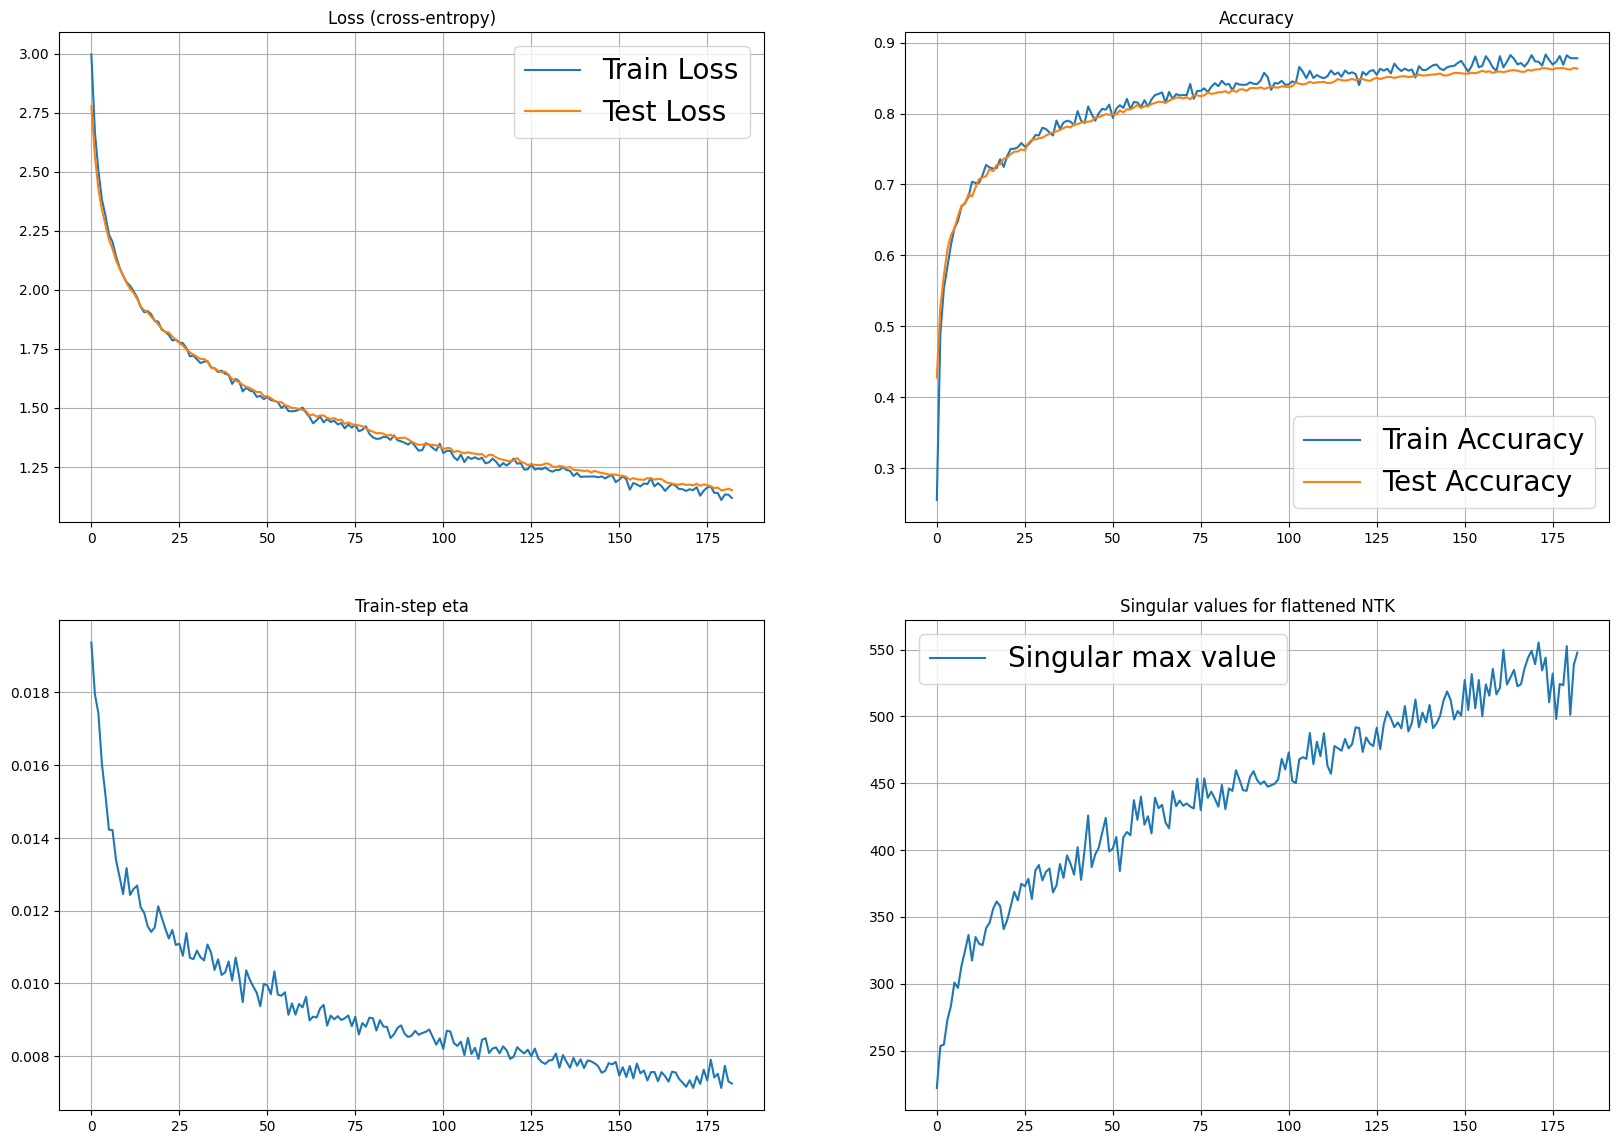

Test accuracy = 0.863407256965813


KeyboardInterrupt: 

In [22]:
logging.info("Initial warmup: subset-size={}, cycles={}".format(BATCH_SIZE, WARMUP_CYCLES))
warmup_iter_number = 0
for train_batch in train_dataloader:
    if warmup_iter_number >= WARMUP_CYCLES:
        break
    warmup_iter_number += 1
    images, labels_raw = train_batch
    labels = torch.tensor([x-1 for x in labels_raw])
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    accuracy_train, mse_train = twoStepsIter(testNet, images, labels, warmup_iter_number)
    logging.info("On warmup iteration {} accuracy_train = {}, mse_train = {}"\
                 .format(warmup_iter_number, accuracy_train, mse_train))

etas = [0.0, 0.0]
sungular_latest = 0.0
stepCalc0 = StepCalculatorEtaAveragedNtk(meta, ntk_recalc_steps_period = NTK_RECALC_STEPS_PERIOD)
epoch_count = 0
for epoch in range(NUM_EPOCH):
    # AverageMeter will accumulate average of some metric
    # Check implementation in `utils.py`
    train_loss_meter, train_accuracy_meter, eta_meter, singular_meter = \
        AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    # training loop
    iter_number = 0
    for train_batch in train_dataloader:
        if iter_number >= 40:
            break
        iter_number += 1        
        images, labels_raw = train_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)
        testNet.grad_zero
        logits = testNet.forward_(xx)

        etas, HL_latest = stepCalc0.step(testNet, labels, logits, etas)
        eta_meter.update(etas[0])

        if not(HL_latest is None):
            HL2d = flatten2d(HL_latest)
            sungulars = svdvals(HL2d)
            sungular_latest = np.max(sungulars)
        singular_meter.update(sungular_latest)

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits.detach().numpy())
        prediction = logits.argmax(dim=-1).detach()
        loss = loss_crossentropy(zz_logits, labels)
        train_loss_meter.update(loss)
        train_accuracy_meter.update(
            calculate_accuracy(
                prediction,
                labels
            )
        )
    # save average train loss and accuracy
    HISTORY_PARAMS['train_loss'].append(train_loss_meter.avg)
    HISTORY_PARAMS['train_accuracy'].append(train_accuracy_meter.avg)
    HISTORY_PARAMS['train_eta'].append(eta_meter.avg)
    HISTORY_PARAMS['train_ntk_sungular_max'].append(singular_meter.avg)

    # testing loop
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels_raw = test_batch
        labels = torch.tensor([x-1 for x in labels_raw])
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            # do everything like we did in training loop
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(
                calculate_accuracy(
                    prediction,
                    labels
                )
            )

    # save average test accuracy loss and accuracy
    HISTORY_PARAMS['test_loss'].append(test_loss_meter.avg)
    HISTORY_PARAMS['test_accuracy'].append(test_accuracy_meter.avg)
    
    visualise(HISTORY_PARAMS)
    print("Test accuracy = {}".format(test_accuracy_meter.avg))

    if epoch_count > 10:
        testNet.save_txt('#current_saved/accuracy_eta_calculated')
        save_dict(HISTORY_PARAMS, '#current_saved/accuracy_eta_calculated')
        epoch_count = 0
    else:
        epoch_count += 1
    

In [11]:
testNet.save_txt('#current_saved/accuracy_eta_calculated')
save_dict(HISTORY_PARAMS, '#current_saved/accuracy_eta_calculated')

In [23]:
print("Accuracy achieved in FFN at Relu-criticality: "+str(HISTORY_PARAMS['test_accuracy'][-1]))

Accuracy achieved in FFN at Relu-criticality: 0.863407256965813
